# Gaussian Processes Summer School

## Part 5: Non-stationary Kernels

<a href="https://www.uc3m.es/"><img src="./uc3m.png" alt="Universidad Carlos III de Madrid" width="520"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)  
**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

### A one-dimensional Gaussian process with input-dependent smoothness

We construct a collection of signals that are smooth at both ends of the input domain and much rougher around its center. The change is produced by a valid non-stationary covariance function, not by stitching together unrelated processes.

## Learning goals

1. Distinguish stationarity from non-stationarity in a covariance function.
2. Use the Gibbs kernel to encode a lengthscale that varies with the input.
3. Sample a database of signals from the resulting GP.
4. Diagnose non-stationarity from sample paths, the covariance matrix, and local covariance slices.
5. Quantify the error made by RBF, spectral-mixture, and implicit **stationary** kernels.

In [286]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

seed = 7
rng = np.random.default_rng(seed)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. From stationary to non-stationary covariance

A stationary kernel has the form

$$k(x,x')=k(x-x').$$

Consequently, every pair of inputs separated by the same lag has the same covariance, regardless of where that pair lies. For example, an RBF kernel uses one global lengthscale $\ell$:

$$k_{\mathrm{RBF}}(x,x')=\sigma_f^2\exp\left[-\frac{(x-x')^2}{2\ell^2}\right].$$

To allow the local smoothness to change with position, we replace the global lengthscale with a positive function $\ell(x)$. A valid covariance that implements this idea is the one-dimensional **Gibbs kernel**:

$$
k_{\mathrm{Gibbs}}(x,x')=\sigma_f^2
\sqrt{\frac{2\ell(x)\ell(x')}{\ell(x)^2+\ell(x')^2}}
\exp\left[-\frac{(x-x')^2}{\ell(x)^2+\ell(x')^2}\right].
$$

It reduces to the RBF kernel when $\ell(x)$ is constant. Otherwise it depends on the absolute locations $x$ and $x'$, so it is non-stationary. Its diagonal remains $k(x,x)=\sigma_f^2$: only smoothness changes here, while marginal signal variance stays constant.

### Intuition for the square-root term

The factor

$$c(x,x')=\sqrt{\frac{2\ell(x)\ell(x')}{\ell(x)^2+\ell(x')^2}}$$

measures how compatible the two **local notions of smoothness** are. Imagine that each input carries a Gaussian smoothing window whose width is $\ell(x)$. By the arithmetic--geometric mean inequality,

$$0<c(x,x')\leq 1.$$

If $\ell(x)=\ell(x')$, then $c(x,x')=1$: the two locations agree about the local scale and no penalty is needed. If one lengthscale is much larger than the other, then $c(x,x')$ approaches zero: a very smooth region and a very rough region share less covariance than distance alone would suggest. At $x=x'$, both lengthscales are necessarily equal, so the factor is exactly one and preserves $k(x,x)=\sigma_f^2$. This term is also part of what makes the input-dependent construction a valid positive-definite kernel; simply inserting a varying lengthscale into an RBF exponent would not generally be sufficient.

### Design an input-dependent lengthscale

We use a smooth Gaussian-shaped dip in the lengthscale,

$$\ell(x)=\ell_{\min}+(\ell_{\max}-\ell_{\min})\left[1-\exp\left(-\frac{x^2}{2r^2}\right)\right],$$

where $r$ controls the width of the rough central region. We use $\ell_{\max}=1.20$, $\ell_{\min}=0.10$, and $r=0.55$. Hence $\ell(0)=\ell_{\min}$, while $\ell(x)$ rapidly approaches $\ell_{\max}$ toward both ends. This high--low--high profile forces a stationary model to compromise between two smooth outer regions and a sharply rough center.

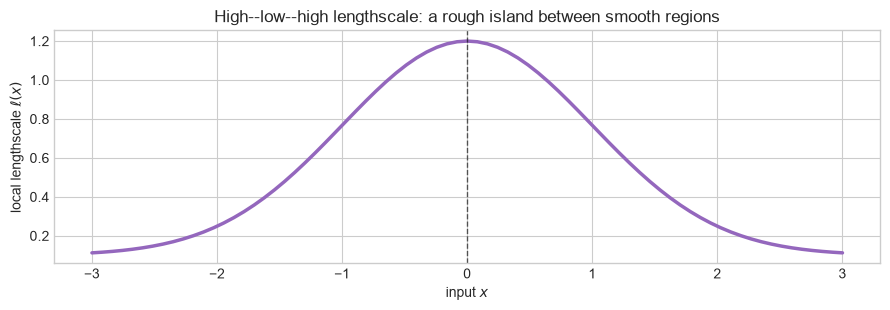

In [504]:
n_points = 75
x = np.linspace(-3.0, 3.0, n_points)

ell_min = 0.1
ell_max = 1.2
lengthscale_dip_width = 1.0
signal_std = 1.0
noise_std = 0.03

def lengthscale_function(x):
    central_dip = np.exp(-0.5 * (x / lengthscale_dip_width)**2)
    return (ell_min + (ell_max - ell_min) * (central_dip))

local_lengthscale = lengthscale_function(x)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(x, local_lengthscale, linewidth=2.5, color="tab:purple")
ax.axvline(0.0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set(xlabel=r"input $x$", ylabel=r"local lengthscale $\ell(x)$",
       title="High--low--high lengthscale: a rough island between smooth regions")
fig.tight_layout()
plt.show()

### Build the covariance and sample the dataset

Every curve below is an independent draw from the same GP,

$$f_i\sim\mathcal{GP}(0,k_{\mathrm{Gibbs}}),\qquad y_i(x)=f_i(x)+\epsilon_i(x),$$

where $\epsilon_i(x)\sim\mathcal N(0,\sigma_n^2)$. Thus every signal shares the same smooth--rough--smooth arrangement, while the particular shape of each curve is random.

In [ ]:
def gibbs_kernel(x1, x2, lengthscale_fn, outputscale=1.0):
    x1 = np.asarray(x1, dtype=float)[:, None]
    x2 = np.asarray(x2, dtype=float)[None, :]
    ell1 = lengthscale_fn(x1)
    ell2 = lengthscale_fn(x2)
    ell_squared_sum = ell1**2 + ell2**2
    normalization = np.sqrt(2.0 * ell1 * ell2 / ell_squared_sum)
    return outputscale**2 * normalization * np.exp(-(x1 - x2)**2 / ell_squared_sum) 

K = gibbs_kernel(x, x, lengthscale_function, outputscale=signal_std)
K = 0.5 * (K + K.T)  # remove floating-point asymmetry

n_signals = 300
jitter = 1e-9
L = np.linalg.cholesky(K + jitter * np.eye(n_points))
latent_signals = rng.standard_normal((n_signals, n_points)) @ L.T
observed_signals = latent_signals + noise_std * rng.standard_normal(latent_signals.shape)

dataset_summary = pd.DataFrame({
    "quantity": ["signals", "points per signal", "input interval",
                 "min / max lengthscale", "signal std", "noise std"],
    "value": [n_signals, n_points, "[-3, 3]",
              f"{local_lengthscale.min():.3f} / {local_lengthscale.max():.3f}",
              signal_std, noise_std],
})
display(dataset_summary)
print("latent_signals shape:", latent_signals.shape)
print("observed_signals shape:", observed_signals.shape)

,quantity,value
0,signals,300
1,points per signal,75
2,input interval,"[-3, 3]"
3,min / max lengthscale,0.112 / 1.200
4,signal std,1.0
5,noise std,0.03


latent_signals shape: (300, 75)
observed_signals shape: (300, 75)


### Sample paths

The large lengthscale near both boundaries suppresses rapid variation. Around $x=0$, nearby inputs decorrelate much faster and the paths develop a concentrated island of fine-scale structure. The faint dots show noisy observations and the solid lines show their latent GP functions.

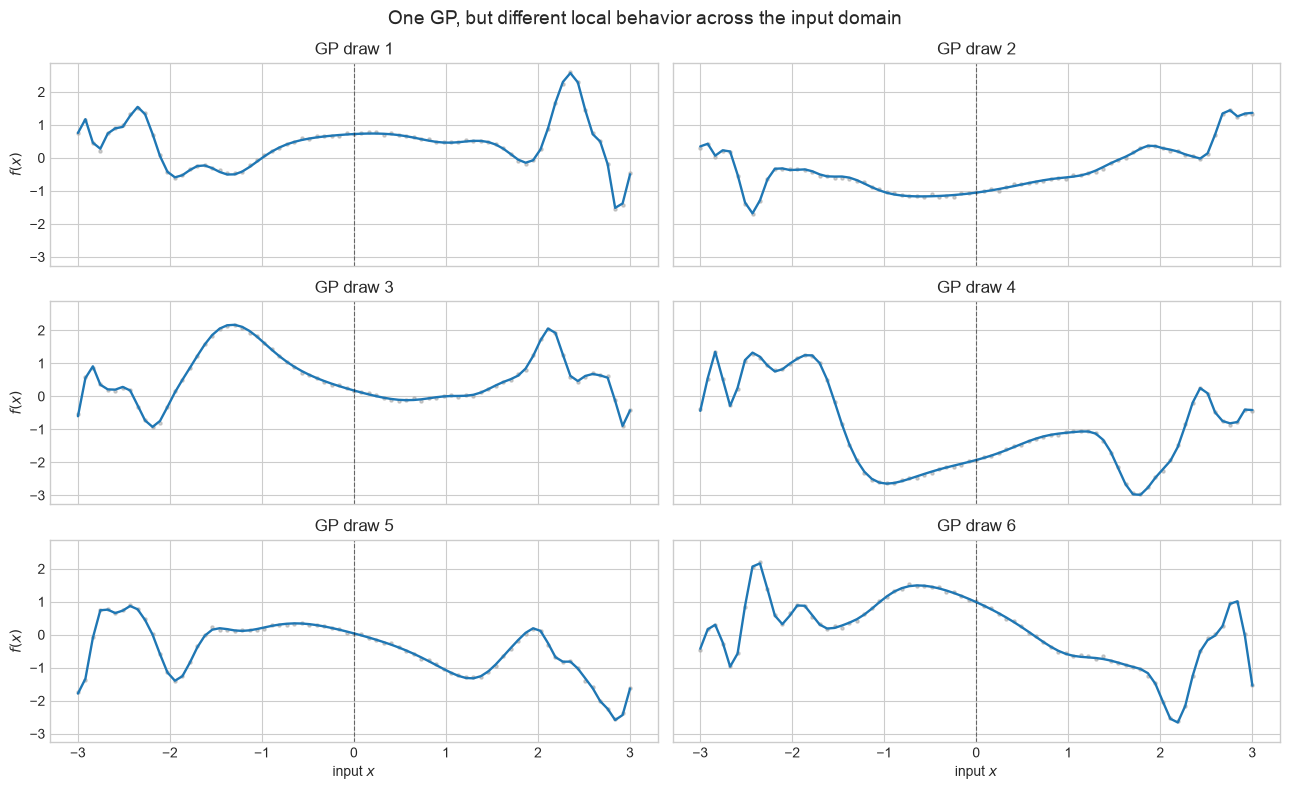

In [506]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=True, sharey=True)
for signal_index, ax in enumerate(axes.flat):
    ax.scatter(x, observed_signals[signal_index], s=5, color="0.65", alpha=0.55)
    ax.plot(x, latent_signals[signal_index], linewidth=1.7, color="tab:blue")
    ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(f"GP draw {signal_index + 1}")
for ax in axes[-1]:
    ax.set_xlabel(r"input $x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$f(x)$")
fig.suptitle("One GP, but different local behavior across the input domain", fontsize=14)
fig.tight_layout()
plt.show()

### The equal-lag test

Stationarity would require $k(x_0,x_0+\tau)$ to be identical for every anchor location $x_0$. We evaluate it around three anchors. Covariance decays slowly at the two smooth anchors $x_0=-2$ and $x_0=2$, but rapidly at the rough central anchor $x_0=0$. Equal lags therefore behave differently across space, directly disproving stationarity.

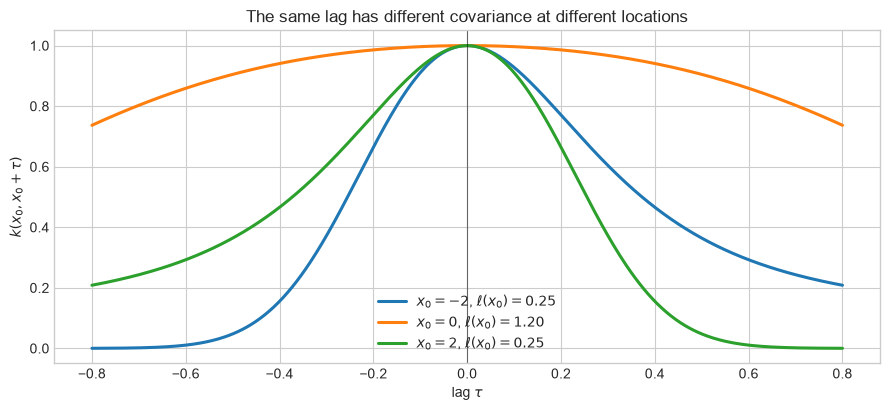

In [507]:
anchors = [-2.0, 0.0, 2.0]
tau = np.linspace(-0.8, 0.8, 500)

fig, ax = plt.subplots(figsize=(9, 4.2))
for anchor in anchors:
    covariance_slice = gibbs_kernel(
        np.array([anchor]), anchor + tau, lengthscale_function, signal_std
    ).ravel()
    ax.plot(tau, covariance_slice, linewidth=2.2,
            label=rf"$x_0={anchor:g}$, $\ell(x_0)={lengthscale_function(anchor):.2f}$")
ax.axvline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set(xlabel=r"lag $\tau$", ylabel=rf"$k(x_0,x_0+\tau)$",
       title="The same lag has different covariance at different locations")
ax.legend()
fig.tight_layout()
plt.show()

### See non-stationarity in the covariance matrix

For a stationary RBF kernel sampled on a regular grid, the covariance matrix has a constant-width band along its diagonal. Here the diagonal band is wide near both corners but pinches sharply around the center: correlation persists over large distances in the two smooth outer regions and over much shorter distances in the rough central region.

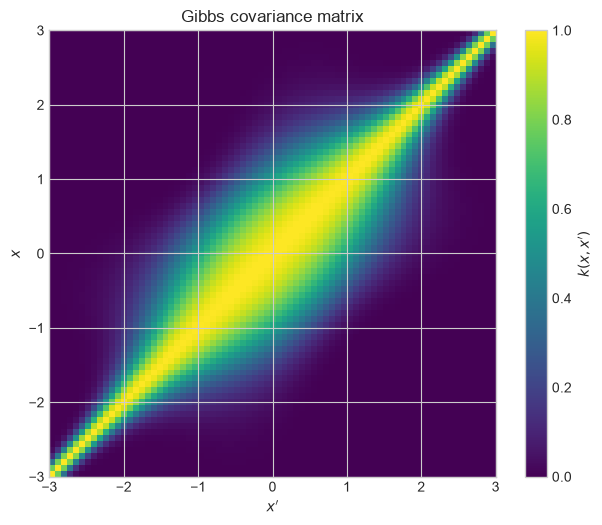

In [508]:
fig, ax = plt.subplots(figsize=(6.5, 5.3))
image = ax.imshow(K, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
                  cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="equal")
ax.set(xlabel=r"$x'$", ylabel=r"$x$", title="Gibbs covariance matrix")
fig.colorbar(image, ax=ax, label=r"$k(x,x')$")
fig.tight_layout()
plt.show()

## 7. How well can stationary spectral kernels fit these data?

We now deliberately misspecify the model class. All three competitors are stationary, so each must use the same covariance at a given lag everywhere on the domain:

- **A. RBF RFF:** a zero-centered Gaussian spectral density, represented with random Fourier features.
- **B. Five locally periodic components:** a weighted sum of five symmetric Gaussian spectral bands.
- **C. Implicit spectral kernel:** a neural network transforms Gaussian noise into a flexible frequency distribution.

Models B and C have much more flexible stationary spectra than model A, but none can make its spectrum depend on $x$. This experiment separates **spectral flexibility** from the ability to represent **non-stationarity**.

In [509]:
import gpytorch
import torch

from train_gp_models import (
    as_gp_tensors,
    build_rff_gp,
    build_symmetric_spectral_mixture_rff_gp,
    learned_hyperparameters,
    learned_spectral_mixture_parameters,
    mean_negative_log_likelihood,
    train_shared_gp,
)
from train_implicit_spectral_gp import (
    build_implicit_spectral_gp,
    train_implicit_spectral_gp,
)

# CPU is predictable for the small exact linear algebra used here.
# Change this to torch.device("cuda") if desired.
if torch.cuda.is_available():
    model_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    model_device = torch.device("mps")
else:
    model_device = torch.device("cpu")
model_dtype = torch.float32  # required on MPS; also sufficient for this experiment
torch.manual_seed(seed)
print("GPyTorch:", gpytorch.__version__, "| device:", model_device, "| dtype:", model_dtype)

GPyTorch: 1.15.2 | device: mps | dtype: torch.float32


### Shared train/test split

We split by complete curves. The models learn one shared kernel from the training population and are evaluated on unseen GP realizations. To keep this teaching notebook quick to rerun, 120 curves are used for fitting and 60 for testing; both subsets come from the original population of 300.

In [510]:
split_rng = np.random.default_rng(seed + 100)
permutation = split_rng.permutation(n_signals)
split_index = np.floor(n_signals * 0.8).astype(int)
fit_indices = permutation[:split_index]
test_indices = permutation[split_index:n_signals]

fit_curves = observed_signals[fit_indices]
test_curves = observed_signals[test_indices]
train_x_tensor, fit_curves_tensor = as_gp_tensors(
    x, fit_curves, dtype=model_dtype, device=model_device
)
_, test_curves_tensor = as_gp_tensors(
    x, test_curves, dtype=model_dtype, device=model_device
)
print(f"fit curves: {len(fit_curves)} | test curves: {len(test_curves)}")

fit curves: 240 | test curves: 60


### Fit A: stationary RBF RFF kernel

The model learns a single global RBF lengthscale. We draw 240 frequencies and use their paired sine and cosine features, ensuring that the approximation depends only on $x-x'$.

In [511]:
num_rff_features = 240  # x2 frequencies, each producing sine and cosine features
rbf_model, rbf_likelihood = build_rff_gp(
    train_x_tensor,
    fit_curves_tensor,
    num_features=num_rff_features,
    seed=seed + 110,
    initial_lengthscale=0.25,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
rbf_losses = train_shared_gp(
    rbf_model, rbf_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.04, print_every=100,
)

step    1/1000 | loss=12.8095 | ell=0.2413 | scale=1.0255 | noise=0.00094
step  100/1000 | loss=0.1340 | ell=0.1059 | scale=1.0976 | noise=0.00210
step  200/1000 | loss=0.1162 | ell=0.1056 | scale=0.7526 | noise=0.00214
step  300/1000 | loss=0.1160 | ell=0.1056 | scale=0.7452 | noise=0.00219
step  400/1000 | loss=0.1159 | ell=0.1056 | scale=0.7439 | noise=0.00223
step  500/1000 | loss=0.1159 | ell=0.1056 | scale=0.7431 | noise=0.00225
step  600/1000 | loss=0.1159 | ell=0.1056 | scale=0.7427 | noise=0.00227
step  700/1000 | loss=0.1159 | ell=0.1056 | scale=0.7425 | noise=0.00227
step  800/1000 | loss=0.1159 | ell=0.1056 | scale=0.7424 | noise=0.00227
step  900/1000 | loss=0.1159 | ell=0.1056 | scale=0.7424 | noise=0.00228
step 1000/1000 | loss=0.1159 | ell=0.1056 | scale=0.7424 | noise=0.00228


### Fit B: stationary mixture of five locally periodic kernels

Each component learns its spectral center, bandwidth, and mixture weight. We allocate 60 frequencies to each component, keeping the total at 300 sampled frequencies. The five initial bandwidths span a finer range from very smooth to very rough behavior.

In [512]:
num_components = 5
lp_model, lp_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    fit_curves_tensor,
    initial_component_means=torch.tensor([0.1, 0.5, 1.5, 4.0, 10.0]),
    num_frequencies_per_component=num_rff_features // num_components,
    spectral_variance=torch.tensor([0.5, 2.0, 8.0, 32.0, 128.0]),
    learn_spectral_variance=True,
    initial_weights=torch.full((num_components,), 1.0 / num_components),
    seed=seed + 120,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
lp_losses = train_shared_gp(
    lp_model, lp_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.015, print_every=100,
)

step    1/1000 | loss=0.2206 | spectral_means=[ 0.101  0.494  1.512  4.015 10.015] | variances=[  0.506   2.013   8.015  32.015 127.985] | weights=[0.201 0.201 0.201 0.201 0.195] | noise=0.00091
step  100/1000 | loss=0.0869 | spectral_means=[ 0.208  0.161  2.231  4.597 10.395] | variances=[  1.04    3.096   8.832  33.222 126.458] | weights=[0.183 0.231 0.284 0.268 0.034] | noise=0.00270
step  200/1000 | loss=0.0823 | spectral_means=[ 0.125  0.156  2.188  4.493 10.451] | variances=[  0.996   2.93    9.001  33.904 124.807] | weights=[0.191 0.252 0.301 0.227 0.029] | noise=0.00293
step  300/1000 | loss=0.0790 | spectral_means=[ 0.104  0.293  2.196  4.306 10.48 ] | variances=[  0.935   2.824   9.101  35.127 123.412] | weights=[0.186 0.266 0.284 0.234 0.03 ] | noise=0.00285
step  400/1000 | loss=0.0773 | spectral_means=[ 0.096  0.435  2.309  4.262 10.509] | variances=[  0.904   2.918   8.723  35.478 122.274] | weights=[0.178 0.302 0.252 0.237 0.031] | noise=0.00279
step  500/1000 | loss=0.0

### Fit C: stationary implicit spectral kernel

An MLP with four hidden layers maps simple Gaussian noise to frequencies. This can learn a complicated multimodal spectrum without evaluating a spectral density. Paired sine/cosine features still produce a stationary kernel: neural flexibility changes the shape of $k(\tau)$, not its dependence on absolute position.

In [522]:
n_hidden_units = 32 
implicit_model, implicit_likelihood = build_implicit_spectral_gp(
    train_x_tensor,
    fit_curves_tensor,
    noise_dimension=20,
    num_frequencies=num_rff_features,
    hidden_features=(n_hidden_units, n_hidden_units, n_hidden_units, n_hidden_units),  # four hidden MLP layers
    initial_frequency_scale=5.0,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
    seed=seed + 130,
)
implicit_history = train_implicit_spectral_gp(
    implicit_model, implicit_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.004, frequency_penalty_weight=1e-5,
    resampling_seed=seed + 131, print_every=100,
)

step    1/1000 | objective=251.5266 | NLL=251.5266 | freq RMS=0.397 | noise=0.00090
step  100/1000 | objective=0.0838 | NLL=0.0832 | freq RMS=8.256 | noise=0.00098
step  200/1000 | objective=0.0478 | NLL=0.0471 | freq RMS=8.433 | noise=0.00103
step  300/1000 | objective=0.0843 | NLL=0.0838 | freq RMS=7.456 | noise=0.00108
step  400/1000 | objective=0.0144 | NLL=0.0137 | freq RMS=8.058 | noise=0.00114
step  500/1000 | objective=0.0274 | NLL=0.0268 | freq RMS=7.681 | noise=0.00119
step  600/1000 | objective=0.0165 | NLL=0.0157 | freq RMS=8.905 | noise=0.00126
step  700/1000 | objective=-0.0113 | NLL=-0.0119 | freq RMS=7.413 | noise=0.00134
step  800/1000 | objective=-0.0020 | NLL=-0.0026 | freq RMS=7.874 | noise=0.00142
step  900/1000 | objective=-0.0001 | NLL=-0.0007 | freq RMS=7.672 | noise=0.00150
step 1000/1000 | objective=-0.0001 | NLL=-0.0007 | freq RMS=8.195 | noise=0.00157


### Error metrics

Because the data-generating covariance is known, we can measure error directly rather than relying only on likelihood. For a learned signal covariance $\widehat K$, define

$$E_{\mathrm{rel}}=\frac{\|\widehat K-K_{\mathrm{Gibbs}}\|_F}{\|K_{\mathrm{Gibbs}}\|_F}.$$

We also report mean absolute covariance error, held-out negative log likelihood per observation, and relative errors inside a smooth outer block and the rough central block. These regional errors reveal which regime each global stationary compromise fits best. Observation noise is included for test NLL but excluded from covariance error.

In [523]:
stationary_models = {
    "A. RBF RFF": (rbf_model, rbf_likelihood),
    "B. 5-component LP": (lp_model, lp_likelihood),
    "C. Implicit spectrum": (implicit_model, implicit_likelihood),
}

def learned_signal_covariance(model, x_tensor):
    model.eval()
    with torch.no_grad():
        return model.covar_module(x_tensor).to_dense().cpu().numpy()

def relative_frobenius(estimate, target):
    return np.linalg.norm(estimate - target, ord="fro") / np.linalg.norm(target, ord="fro")

smooth_block = np.ix_(x < -1.5, x < -1.5)
rough_block = np.ix_(np.abs(x) < 0.5, np.abs(x) < 0.5)
learned_covariances = {}
comparison_rows = []

for name, (model, likelihood) in stationary_models.items():
    covariance = learned_signal_covariance(model, train_x_tensor)
    learned_covariances[name] = covariance
    comparison_rows.append({
        "model": name,
        "relative kernel error": relative_frobenius(covariance, K),
        "mean absolute error": np.mean(np.abs(covariance - K)),
        "smooth-block error": relative_frobenius(covariance[smooth_block], K[smooth_block]),
        "rough-block error": relative_frobenius(covariance[rough_block], K[rough_block]),
        "test NLL / observation": mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, test_curves_tensor
        ),
    })

comparison_table = pd.DataFrame(comparison_rows).set_index("model")
display(comparison_table.style.format(precision=4).set_caption(
    "Error of stationary models on non-stationary GP data"
))

,relative kernel error,mean absolute error,smooth-block error,rough-block error,test NLL / observation
model,,,,,
A. RBF RFF,0.8322,0.1961,0.5455,0.8157,0.1050
B. 5-component LP,0.4810,0.1247,0.5370,0.4124,-0.0096
C. Implicit spectrum,0.7247,0.1671,0.4342,0.7068,0.0037


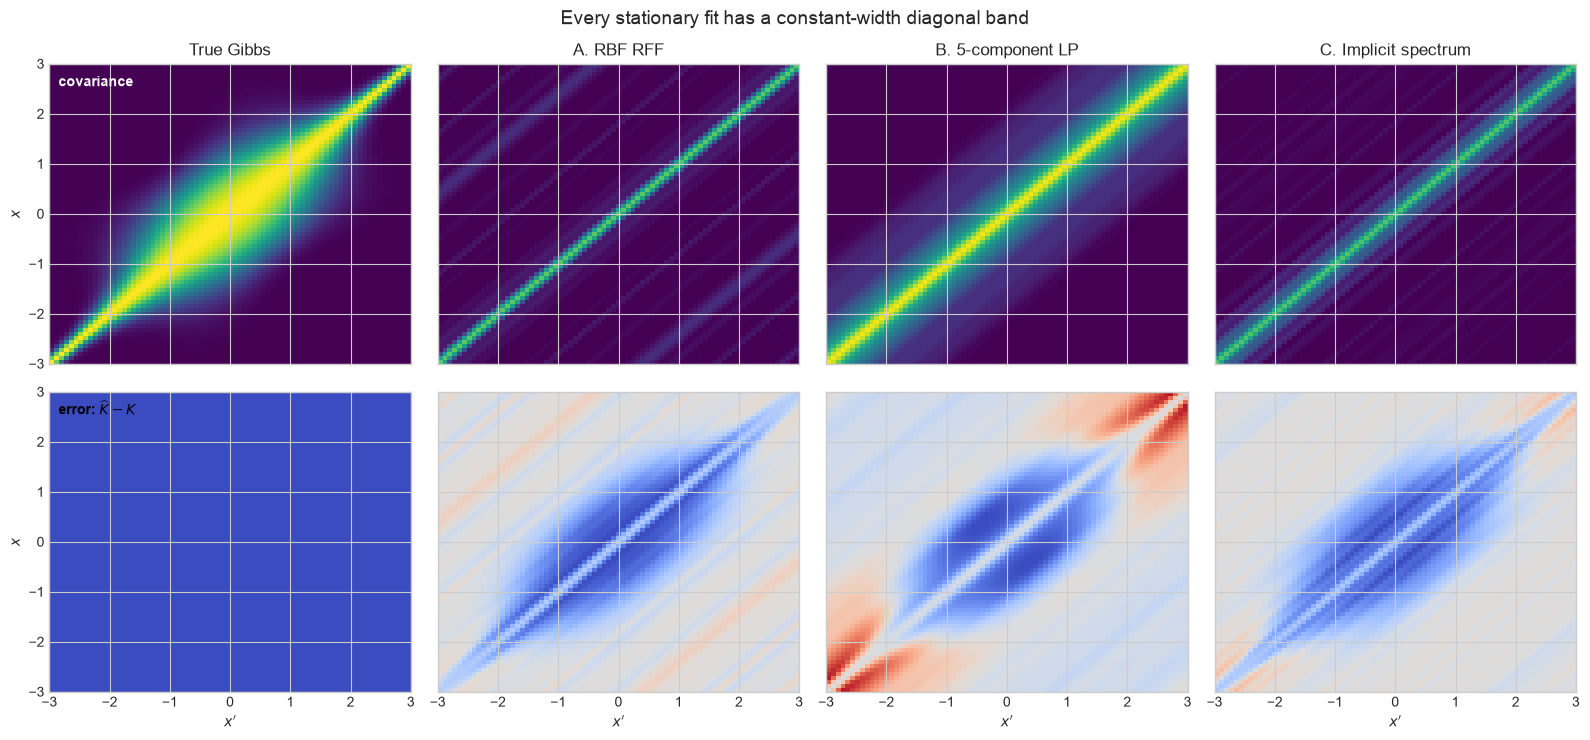

In [524]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True, sharey=True)
all_covariances = {"True Gibbs": K, **learned_covariances}

for column, (name, covariance) in enumerate(all_covariances.items()):
    axes[0, column].imshow(
        covariance, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="auto",
    )
    axes[0, column].set_title(name)
    error = covariance - K
    limit = np.max(np.abs(error))
    axes[1, column].imshow(
        error, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto",
    )
    axes[1, column].set_xlabel(r"$x'$")
axes[0, 0].set_ylabel(r"$x$")
axes[1, 0].set_ylabel(r"$x$")
axes[0, 0].text(-2.85, 2.55, "covariance", color="white", weight="bold")
axes[1, 0].text(-2.85, 2.55, r"error: $\widehat K-K$", color="black", weight="bold")
fig.suptitle("Every stationary fit has a constant-width diagonal band", fontsize=14)
fig.tight_layout()
plt.show()

### Where the error comes from

A stationary kernel can learn only one covariance curve as a function of lag. The next plot overlays that learned global curve on the three true local covariance slices. A flexible stationary spectrum may find a better global compromise, but it cannot simultaneously match the slow decay in both outer regions and the rapid decay at the center.

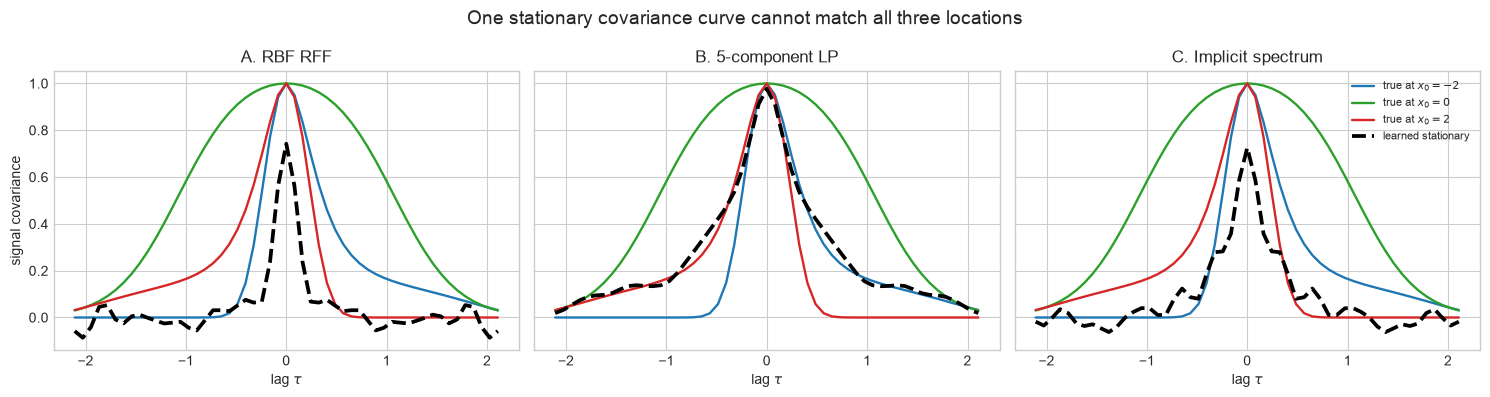

In [525]:
center_index = np.argmin(np.abs(x))
lag_indices = np.arange(-26, 27)
valid_lag_indices = center_index + lag_indices
lag_grid = x[valid_lag_indices] - x[center_index]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (name, covariance) in zip(axes, learned_covariances.items()):
    for anchor, color in zip(anchors, ["tab:blue", "tab:green", "tab:red"]):
        true_slice = gibbs_kernel(
            np.array([anchor]), anchor + lag_grid, lengthscale_function, signal_std
        ).ravel()
        ax.plot(lag_grid, true_slice, color=color, linewidth=1.7,
                label=rf"true at $x_0={anchor:g}$")
    stationary_slice = covariance[center_index, valid_lag_indices]
    ax.plot(lag_grid, stationary_slice, color="black", linewidth=2.7,
            linestyle="--", label="learned stationary")
    ax.set_title(name)
    ax.set_xlabel(r"lag $\tau$")
axes[0].set_ylabel("signal covariance")
axes[-1].legend(loc="upper right", fontsize=8)
fig.suptitle("One stationary covariance curve cannot match all three locations", fontsize=14)
fig.tight_layout()
plt.show()

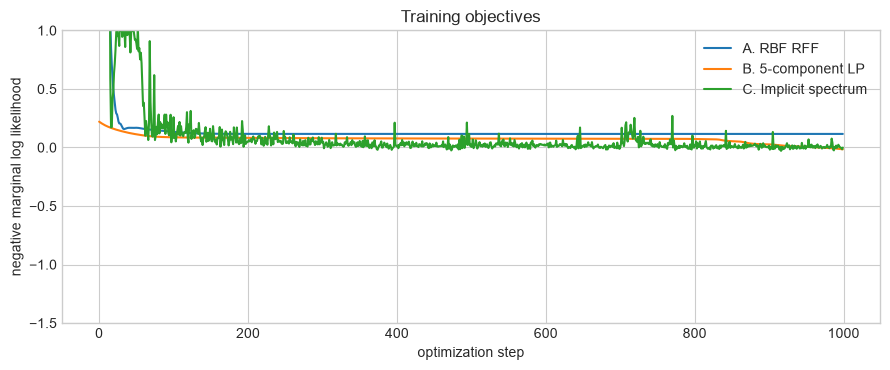

A. RBF parameters: {'mean': -0.03207781910896301, 'lengthscale': 0.10562831163406372, 'outputscale': 0.7423952221870422, 'noise': 0.0022756659891456366}
B. Locally periodic mixture parameters:
  mean: -0.0317
  component_means: [ 0.0833  1.0502  6.4227  9.4032 15.9263]
  mixture_weights: [0.2919 0.4563 0.1759 0.0712 0.0048]
  spectral_variances: [  0.9045   6.1354  11.9728  36.8978 117.1187]
  outputscale: 0.977
  noise: 0.0016
C. Implicit frequency RMS: 8.213900566101074


In [526]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(rbf_losses, label="A. RBF RFF")
ax.plot(lp_losses, label="B. 5-component LP")
ax.plot(implicit_history.negative_mll, label="C. Implicit spectrum")
ax.set_ylim(-1.5, 1)
ax.set(xlabel="optimization step", ylabel="negative marginal log likelihood",
       title="Training objectives")
ax.legend()
fig.tight_layout()
plt.show()

print("A. RBF parameters:", learned_hyperparameters(rbf_model, rbf_likelihood))
print("B. Locally periodic mixture parameters:")
for key, value in learned_spectral_mixture_parameters(lp_model, lp_likelihood).items():
    print(f"  {key}: {np.round(value, 4) if isinstance(value, np.ndarray) else round(value, 4)}")
implicit_kernel = implicit_model.covar_module.base_kernel
print("C. Implicit frequency RMS:",
      float(implicit_kernel.frequency_l2().detach().sqrt().cpu()))

## 8. Non-stationary spectral kernels

There are many papers proposing spectral constructions for non-stationary kernels. We focus on the particular construction developed in **our NeurIPS 2025 paper, _Multi-View-Oriented GPLVM: Expressiveness and Efficiency_**. Although the paper uses the kernel inside a GPLVM, that application is not important here: for now, we study only the underlying kernel. We choose this formulation because its spectral representation is especially convenient and, crucially, Theorem 2 provides a direct random Fourier feature map.

### From one frequency to a pair of frequencies

Ordinary Bochner's theorem represents a stationary kernel using one frequency $\mathbf w$:

$$k(\mathbf x_1,\mathbf x_2)=\int \exp\left(i\mathbf w^\top(\mathbf x_1-\mathbf x_2)\right)p(\mathbf w)\,d\mathbf w.$$

The same frequency multiplies both inputs, so the result can depend only on their difference. The central idea for obtaining non-stationarity is to work instead with a **pair** $(\mathbf w_1,\mathbf w_2)$ drawn jointly from a bivariate spectral object. The two inputs can then interact with different, statistically coupled frequencies.

### Theorem 1: the spectral representation

Theorem 1 of the paper states that a bounded continuous complex-valued kernel $k(\mathbf x_1,\mathbf x_2)$ on $\mathbb R^D$ is the covariance of a mean-square continuous complex-valued random process if and only if it can be written as

$$
\begin{aligned}
k(\mathbf x_1,\mathbf x_2)=\frac14\int &\Big[
e^{i(\mathbf w_1^\top\mathbf x_1-\mathbf w_2^\top\mathbf x_2)}
+e^{i(\mathbf w_2^\top\mathbf x_1-\mathbf w_1^\top\mathbf x_2)}\\
&+e^{i\mathbf w_1^\top(\mathbf x_1-\mathbf x_2)}
+e^{i\mathbf w_2^\top(\mathbf x_1-\mathbf x_2)}
\Big]\,u(d\mathbf w_1,d\mathbf w_2).
\end{aligned}
$$

Here $u$ is a bivariate Lebesgue--Stieltjes measure associated with the spectral construction. A general bivariate measure does **not** necessarily admit a probability density with respect to Lebesgue measure; it may, for example, contain singular or discrete parts. In this notebook we deliberately restrict attention to the absolutely continuous case in which the normalized measure admits a joint probability density $p(\mathbf w_1,\mathbf w_2)$, so that

$$u(d\mathbf w_1,d\mathbf w_2)=p(\mathbf w_1,\mathbf w_2)\,d\mathbf w_1d\mathbf w_2.$$

Under this assumption, the integral can be read as an expectation over jointly distributed frequency pairs $(\mathbf w_1,\mathbf w_2)\sim p$. This density assumption is convenient for sampling and is the case we will use below, but it is an assumption on our construction rather than a property of every possible spectral measure.

### Where does non-stationarity enter?

The first two terms contain

$$\mathbf w_1^\top\mathbf x_1-\mathbf w_2^\top\mathbf x_2,$$

rather than a single frequency multiplying $\mathbf x_1-\mathbf x_2$. When $\mathbf w_1\neq\mathbf w_2$, translating both inputs by the same vector $\mathbf c$ adds $(\mathbf w_1-\mathbf w_2)^\top\mathbf c$ to the phase. The covariance can therefore change under a common translation and can depend on the absolute input locations: it is non-stationary.

The last two terms are ordinary stationary contributions, one from each marginal frequency. Together, the four terms symmetrize the roles of the two inputs and frequencies and lead to the feature representation below. In the special case $\mathbf w_1=\mathbf w_2=\mathbf w$, all four terms coincide and Theorem 1 reduces to the usual Bochner representation. Thus ordinary stationary spectral kernels sit inside this larger family as the diagonal case of the joint spectral distribution.

### Theorem 2: a convenient RFF map

Theorem 2 is the practical reason we use this construction. Draw $L/2$ independent frequency pairs

$$\left\{(\mathbf w_1^{(l)},\mathbf w_2^{(l)})\right\}_{l=1}^{L/2}\overset{\mathrm{i.i.d.}}{\sim}p(\mathbf w_1,\mathbf w_2),$$

and define the $L$-dimensional real feature map. Writing every entry explicitly makes the stacking clear:

$$
\boldsymbol\phi(\mathbf x)=\sqrt{\frac{1}{2L}}
\begin{bmatrix}
\cos((\mathbf w_1^{(1)})^\top\mathbf x)+\cos((\mathbf w_2^{(1)})^\top\mathbf x)\\
\cos((\mathbf w_1^{(2)})^\top\mathbf x)+\cos((\mathbf w_2^{(2)})^\top\mathbf x)\\
\vdots\\
\cos((\mathbf w_1^{(L/2)})^\top\mathbf x)+\cos((\mathbf w_2^{(L/2)})^\top\mathbf x)\\[3pt]
\sin((\mathbf w_1^{(1)})^\top\mathbf x)+\sin((\mathbf w_2^{(1)})^\top\mathbf x)\\
\sin((\mathbf w_1^{(2)})^\top\mathbf x)+\sin((\mathbf w_2^{(2)})^\top\mathbf x)\\
\vdots\\
\sin((\mathbf w_1^{(L/2)})^\top\mathbf x)+\sin((\mathbf w_2^{(L/2)})^\top\mathbf x)
\end{bmatrix}\in\mathbb R^L.
$$

The first $L/2$ coordinates are cosine features and the final $L/2$ coordinates are sine features. Importantly, coordinate $l$ combines the two frequencies from the **same joint draw** $(\mathbf w_1^{(l)},\mathbf w_2^{(l)})$; we are not stacking separate feature vectors for all $\mathbf w_1$ samples and then all $\mathbf w_2$ samples. Equivalently, if

$$\mathbf W_j=[\mathbf w_j^{(1)},\ldots,\mathbf w_j^{(L/2)}]\in\mathbb R^{D\times L/2},\qquad j\in\{1,2\},$$

then each expression such as $\cos(\mathbf W_j^\top\mathbf x)$ denotes an $L/2$-dimensional vector, with cosine applied elementwise. The resulting inner product is an unbiased Monte Carlo estimator:

$$k(\mathbf x_1,\mathbf x_2)\approx\boldsymbol\phi(\mathbf x_1)^\top\boldsymbol\phi(\mathbf x_2).$$

This looks very close to ordinary RFFs, but each feature now combines two jointly drawn frequencies. The cross-products between the $\mathbf w_1$ and $\mathbf w_2$ trigonometric terms generate the non-stationary part of Theorem 1, while the same-frequency products generate its stationary part. We will specify and learn the joint density $p(\mathbf w_1,\mathbf w_2)$ in the next stage.

## 9. Learning paired non-stationary spectral distributions

We now fit four joint spectral models through the feature map in Theorem 2. Every model emits paired frequencies $(w_1,w_2)$, so it can represent covariance that depends separately on $x_1$ and $x_2$. The models differ only in how flexible the joint density $p(w_1,w_2)$ is:

1. One bivariate Gaussian with a diagonal covariance matrix.
2. One bivariate Gaussian with a learned correlation.
3. A marginalized mixture of five correlated bivariate Gaussians.
4. An implicit neural joint spectral distribution.

As before, all kernel parameters are shared across the population of signals and are learned by maximizing their average GP marginal likelihood.

### Differentiable samples from a correlated bivariate Gaussian

For one spectral component, write

$$
\begin{bmatrix}w_1\\w_2\end{bmatrix}
\sim\mathcal N\left(
\begin{bmatrix}\mu_1\\\mu_2\end{bmatrix},
\begin{bmatrix}
\sigma_1^2 & \rho\sigma_1\sigma_2\\
\rho\sigma_1\sigma_2 & \sigma_2^2
\end{bmatrix}
\right).
$$

A direct draw would hide the dependence on the covariance parameters from automatic differentiation. Instead we use the pathwise, or reparameterization, form. Draw parameter-free noise $\epsilon_1,\epsilon_2\overset{\mathrm{i.i.d.}}{\sim}\mathcal N(0,1)$ and set

$$
w_1=\mu_1+\sigma_1\epsilon_1,\qquad
w_2=\mu_2+\sigma_2\left(\rho\epsilon_1+\sqrt{1-\rho^2}\,\epsilon_2\right).
$$

This is a two-dimensional Cholesky reparameterization. The shared $\epsilon_1$ produces $\operatorname{Cov}(w_1,w_2)=\rho\sigma_1\sigma_2$. Every operation is differentiable in $\mu_1,\mu_2,\sigma_1,\sigma_2$, and $\rho$. We parameterize the standard deviations with `softplus` and the correlation as $\rho=0.99\tanh(r)$, which guarantees $\sigma_j>0$ and $|\rho|<1$. For the independent model we simply fix $\rho=0$, giving the diagonal covariance $\operatorname{diag}(\sigma_1^2,\sigma_2^2)$.

In [527]:
from train_paired_spectral_gp import (
    PairedGaussianRFFKernel,
    PairedImplicitRFFKernel,
    build_paired_spectral_gp,
    mean_negative_log_likelihood as paired_mean_negative_log_likelihood,
    train_paired_spectral_gp,
)

num_paired_frequencies = num_rff_features

### Model 1: one independent bivariate Gaussian

The joint density factorizes as $p(w_1,w_2)=p_1(w_1)p_2(w_2)$. The two marginal means and variances can differ, so paired frequencies need not be equal and the induced kernel can still be non-stationary. What this model cannot express is direct statistical coupling between the two frequencies.

In [528]:
independent_kernel = PairedGaussianRFFKernel(
    initial_means=torch.tensor([[0.0, 0.0]]),
    initial_stds=torch.tensor([[2.0, 8.0]]),
    num_pairs_per_component=num_paired_frequencies,
    correlated=False,
    seed=seed + 201,
)
independent_model, independent_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, independent_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
independent_history = train_paired_spectral_gp(
    independent_model, independent_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.015, print_every=100,
)

step    1/1000 | NLL=0.0457 | noise=0.00091
step  100/1000 | NLL=-0.0577 | noise=0.00164
step  200/1000 | NLL=-0.0577 | noise=0.00163
step  300/1000 | NLL=-0.0577 | noise=0.00163
step  400/1000 | NLL=-0.0577 | noise=0.00163
step  500/1000 | NLL=-0.0577 | noise=0.00163
step  600/1000 | NLL=-0.0577 | noise=0.00163
step  700/1000 | NLL=-0.0577 | noise=0.00163
step  800/1000 | NLL=-0.0577 | noise=0.00163
step  900/1000 | NLL=-0.0577 | noise=0.00163
step 1000/1000 | NLL=-0.0577 | noise=0.00163


### Model 2: one correlated bivariate Gaussian

This model learns the off-diagonal covariance through $\rho$. Positive correlation encourages $w_1$ and $w_2$ to move together while still allowing them to differ. The same fixed base-noise samples are transformed at every optimization step, giving a deterministic Monte Carlo objective with gradients through the Cholesky reparameterization above.

In [529]:
correlated_kernel = PairedGaussianRFFKernel(
    initial_means=torch.tensor([[0.0, 0.0]]),
    initial_stds=torch.tensor([[2.0, 8.0]]),
    num_pairs_per_component=num_paired_frequencies,
    correlated=True,
    initial_correlations=torch.tensor([0.7]),
    seed=seed + 202,
)
correlated_model, correlated_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, correlated_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
correlated_history = train_paired_spectral_gp(
    correlated_model, correlated_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.015, print_every=100,
)

step    1/1000 | NLL=0.2825 | noise=0.00091
step  100/1000 | NLL=-0.0015 | noise=0.00198
step  200/1000 | NLL=-0.0028 | noise=0.00220
step  300/1000 | NLL=-0.0028 | noise=0.00222
step  400/1000 | NLL=-0.0028 | noise=0.00222
step  500/1000 | NLL=-0.0028 | noise=0.00222
step  600/1000 | NLL=-0.0028 | noise=0.00222
step  700/1000 | NLL=-0.0028 | noise=0.00222
step  800/1000 | NLL=-0.0028 | noise=0.00222
step  900/1000 | NLL=-0.0028 | noise=0.00222
step 1000/1000 | NLL=-0.0028 | noise=0.00222


### Model 3: a marginalized mixture of correlated Gaussians

Let $p_q(w_1,w_2)$ be five correlated bivariate Gaussian densities centered at different frequencies. We use

$$p(w_1,w_2)=\sum_{q=1}^{5}\alpha_q p_q(w_1,w_2),\qquad \alpha_q=\operatorname{softmax}(a)_q.$$

We do **not** sample $q$. For every component we draw continuous Gaussian base noise, form its Theorem-2 feature block $\boldsymbol\phi_q(x)$, and concatenate

$$\boldsymbol\phi(x)=\left[\sqrt{\alpha_1}\boldsymbol\phi_1(x);\ldots;\sqrt{\alpha_5}\boldsymbol\phi_5(x)\right].$$

Its inner product is $\sum_q\alpha_q\boldsymbol\phi_q(x_1)^\top\boldsymbol\phi_q(x_2)$, the analytically marginalized mixture kernel. The softmax weights, component means, variances, and correlations are all differentiable; no Gumbel--Softmax is involved.

In [530]:
mixture_kernel = PairedGaussianRFFKernel(
    initial_means=torch.tensor([
        [0.0, 0.0], [1.5, 1.5], [3.0, 3.0], [6.0, 6.0], [10.0, 10.0]
    ]),
    initial_stds=torch.tensor([
        [0.8, 1.0], [1.5, 2.0], [3.0, 4.0], [5.0, 7.0], [8.0, 10.0]
    ]),
    num_pairs_per_component=num_paired_frequencies // num_components,
    correlated=True,
    initial_correlations=torch.full((5,), 0.7),
    initial_weights=torch.full((5,), 1.0 / 5.0),
    seed=seed + 203,
)
mixture_model, mixture_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, mixture_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
mixture_history = train_paired_spectral_gp(
    mixture_model, mixture_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.012, print_every=100,
)

step    1/1000 | NLL=0.0294 | noise=0.00091
step  100/1000 | NLL=-0.0950 | noise=0.00137
step  200/1000 | NLL=-0.1005 | noise=0.00137
step  300/1000 | NLL=-0.1052 | noise=0.00137
step  400/1000 | NLL=-0.1054 | noise=0.00137
step  500/1000 | NLL=-0.1055 | noise=0.00137
step  600/1000 | NLL=-0.1055 | noise=0.00137
step  700/1000 | NLL=-0.1055 | noise=0.00137
step  800/1000 | NLL=-0.1055 | noise=0.00137
step  900/1000 | NLL=-0.1055 | noise=0.00137
step 1000/1000 | NLL=-0.1055 | noise=0.00137


### Model 4: an implicit neural joint spectral distribution

Finally, a neural generator maps $\mathbf z\sim\mathcal N(\mathbf0,I)$ directly to a pair,

$$\begin{bmatrix}w_1\\w_2\end{bmatrix}=g_\theta(\mathbf z).$$

The generator uses four hidden MLP layers and can represent nonlinear dependence and non-Gaussian, multimodal joint shapes without requiring us to evaluate $p(w_1,w_2)$. The samples are differentiable because the randomness resides in the parameter-free input $\mathbf z$, while the sampled frequencies are deterministic differentiable functions of $\theta$. A small squared-frequency penalty discourages unnecessarily extreme frequencies.

In [532]:
    
paired_implicit_kernel = PairedImplicitRFFKernel(
    noise_dimension=5, num_pairs=num_paired_frequencies,
    hidden_features=(n_hidden_units, n_hidden_units, n_hidden_units, n_hidden_units),  # four hidden MLP layers
    initial_frequency_scale=10.0, seed=seed + 204,
)
paired_implicit_model, paired_implicit_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, paired_implicit_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
paired_implicit_history = train_paired_spectral_gp(
    paired_implicit_model, paired_implicit_likelihood,
    train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.004, frequency_penalty_weight=1e-4,
    print_every=100,
)

step    1/1000 | NLL=262.6101 | noise=0.00090
step  100/1000 | NLL=0.3414 | noise=0.00098
step  200/1000 | NLL=-0.0461 | noise=0.00102
step  300/1000 | NLL=-0.0529 | noise=0.00105
step  400/1000 | NLL=-0.0595 | noise=0.00109
step  500/1000 | NLL=-0.0673 | noise=0.00115
step  600/1000 | NLL=-0.0726 | noise=0.00121
step  700/1000 | NLL=-0.0785 | noise=0.00127
step  800/1000 | NLL=-0.0832 | noise=0.00132
step  900/1000 | NLL=-0.0879 | noise=0.00137
step 1000/1000 | NLL=-0.0901 | noise=0.00142


### Compare the four non-stationary models

We use the same metrics as in the stationary experiment. The covariance errors exclude observation noise, while held-out NLL includes the learned likelihood noise.

In [533]:
paired_models = {
    "1. Independent Gaussian": (independent_model, independent_likelihood),
    "2. Correlated Gaussian": (correlated_model, correlated_likelihood),
    "3. Five-Gaussian mixture": (mixture_model, mixture_likelihood),
    "4. Implicit neural": (paired_implicit_model, paired_implicit_likelihood),
}

paired_covariances = {}
paired_rows = []
for name, (model, likelihood) in paired_models.items():
    covariance = learned_signal_covariance(model, train_x_tensor)
    paired_covariances[name] = covariance
    paired_rows.append({
        "model": name,
        "relative kernel error": relative_frobenius(covariance, K),
        "mean absolute error": np.mean(np.abs(covariance - K)),
        "smooth-block error": relative_frobenius(covariance[smooth_block], K[smooth_block]),
        "rough-block error": relative_frobenius(covariance[rough_block], K[rough_block]),
        "test NLL / observation": paired_mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, test_curves_tensor
        ),
    })
paired_comparison_table = pd.DataFrame(paired_rows).set_index("model")
display(paired_comparison_table.style.format(precision=4).set_caption(
    "Paired non-stationary spectral models"
))

,relative kernel error,mean absolute error,smooth-block error,rough-block error,test NLL / observation
model,,,,,
1. Independent Gaussian,0.5705,0.1438,0.4125,0.4241,-0.0509
2. Correlated Gaussian,0.6153,0.1519,0.4141,0.4998,0.0071
3. Five-Gaussian mixture,0.3009,0.0611,0.2629,0.5371,-0.0884
4. Implicit neural,0.5002,0.1210,0.3551,0.4104,-0.0777


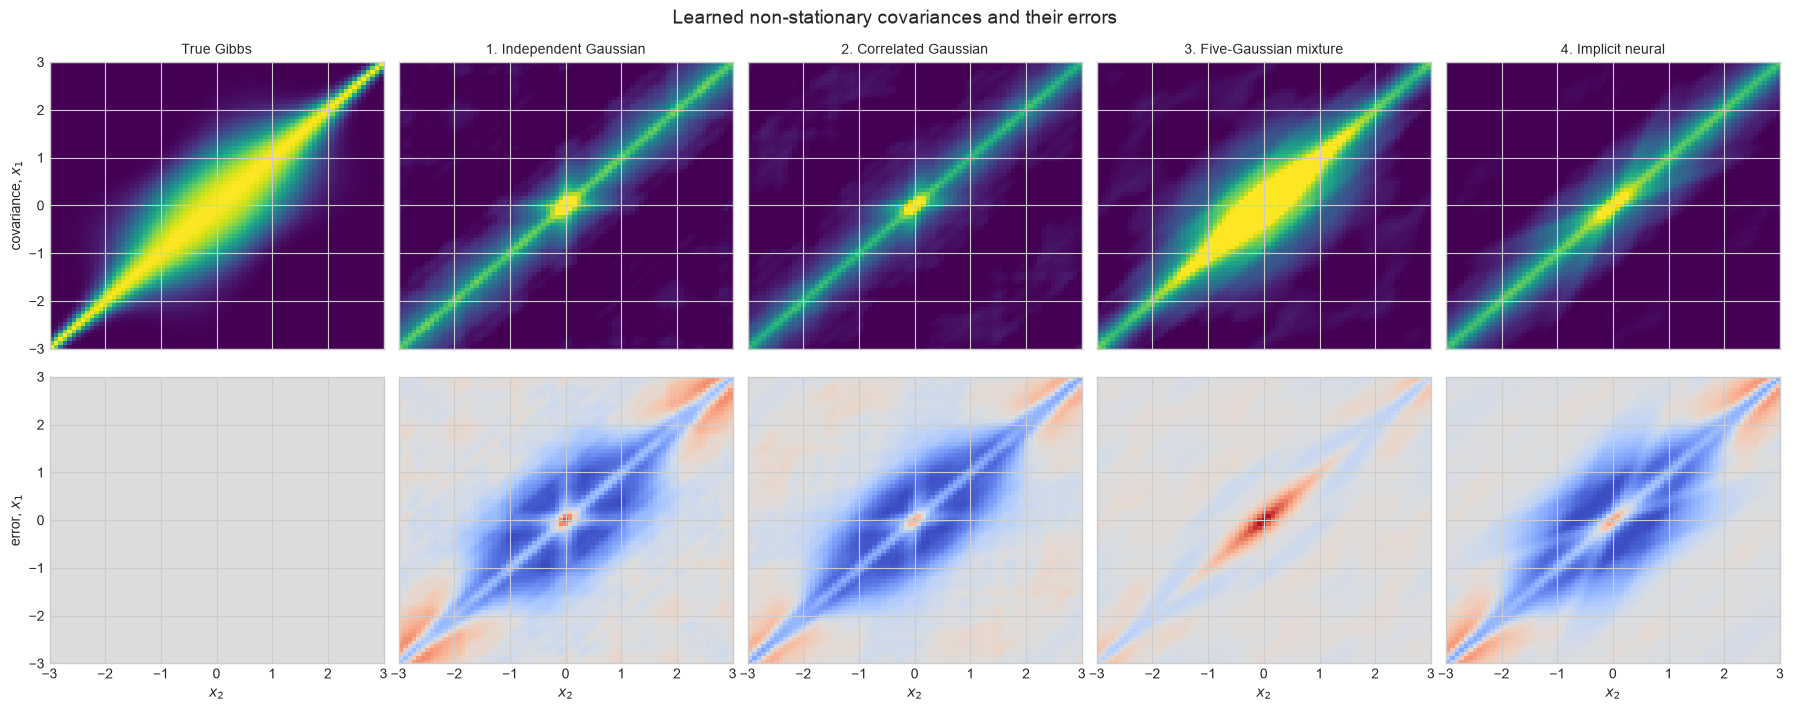

In [534]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7.2), sharex=True, sharey=True)
all_paired_covariances = {"True Gibbs": K, **paired_covariances}
for column, (name, covariance) in enumerate(all_paired_covariances.items()):
    axes[0, column].imshow(
        covariance, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="auto",
    )
    axes[0, column].set_title(name, fontsize=10)
    error = covariance - K
    limit = max(np.max(np.abs(error)), 1e-8)
    axes[1, column].imshow(
        error, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto",
    )
    axes[1, column].set_xlabel(r"$x_2$")
axes[0, 0].set_ylabel(r"covariance, $x_1$")
axes[1, 0].set_ylabel(r"error, $x_1$")
fig.suptitle("Learned non-stationary covariances and their errors", fontsize=14)
fig.tight_layout()
plt.show()

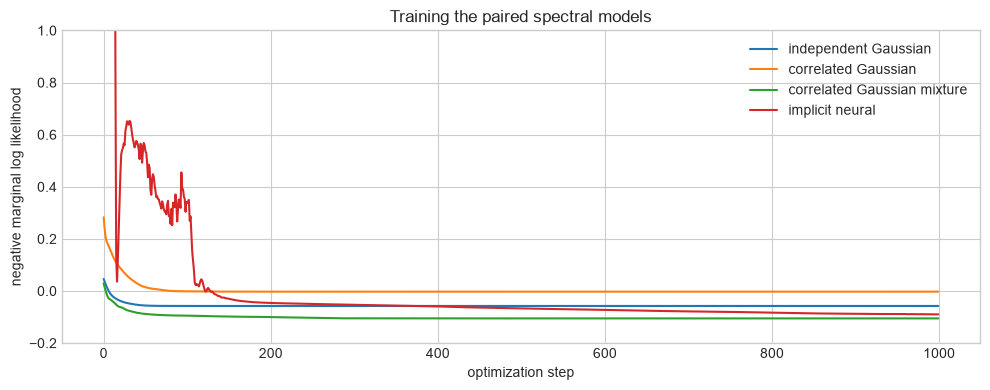

independent:
  means = [[-0.159  0.103]]
  stds  = [[1.765 8.153]]
  rho   = [0.]
  weights = [1.]
correlated:
  means = [[1.048 0.023]]
  stds  = [[2.163 8.559]]
  rho   = [0.659]
  weights = [1.]
mixture:
  means = [[ 1.055 -0.205]
 [ 0.708  1.656]
 [ 2.32   2.496]
 [ 6.14   5.874]
 [ 9.542  9.578]]
  stds  = [[ 0.722  0.665]
 [ 1.949  1.694]
 [ 3.458  4.452]
 [ 5.186  7.236]
 [ 8.226 10.325]]
  rho   = [0.986 0.763 0.612 0.679 0.733]
  weights = [0.395 0.196 0.297 0.077 0.035]


In [536]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(independent_history.loss, label="independent Gaussian")
ax.plot(correlated_history.loss, label="correlated Gaussian")
ax.plot(mixture_history.loss, label="correlated Gaussian mixture")
ax.plot(paired_implicit_history.loss, label="implicit neural")
ax.set(xlabel="optimization step", ylabel="negative marginal log likelihood",
       title="Training the paired spectral models")
ax.set_ylim(-0.2,1)
ax.legend()
fig.tight_layout()
plt.show()

for name, kernel in {
    "independent": independent_kernel,
    "correlated": correlated_kernel,
    "mixture": mixture_kernel,
}.items():
    print(f"{name}:")
    print("  means =", np.round(kernel.means.detach().cpu().numpy(), 3))
    print("  stds  =", np.round(kernel.stds.detach().cpu().numpy(), 3))
    print("  rho   =", np.round(kernel.correlations.detach().cpu().numpy(), 3))
    print("  weights =", np.round(kernel.mixture_weights.detach().cpu().numpy(), 3))

## Takeaway

This dataset has one deliberately isolated source of non-stationarity: its local lengthscale. All signals share the same zero mean, constant marginal variance, and high--low--high lengthscale profile. The resulting smooth--rough--smooth paths make the stationary restriction especially visible: a single lag-covariance curve cannot fit the two broad outer correlation bands and the narrow central band simultaneously.

## 10. GP prediction: selected stationary versus selected non-stationary model

We finish with the task that matters operationally: predicting an unseen signal from sparse observations. The next cell lets the user select any one of the fitted stationary models and any one of the fitted non-stationary models by changing two dictionary keys.

Both selected models are conditioned on exactly the same input locations and observed values. We plot their latent-function posterior means and pointwise 95% credible intervals against the known latent GP draw. 

In [537]:
# Valid stationary_models keys:
#   "A. RBF RFF"
#   "B. 5-component LP"
#   "C. Implicit spectrum"
selected_stationary_name = "B. 5-component LP"

# Valid paired_models keys:
#   "1. Independent Gaussian"
#   "2. Correlated Gaussian"
#   "3. Five-Gaussian mixture"
#   "4. Implicit neural"
selected_nonstationary_name = "3. Five-Gaussian mixture"

if selected_stationary_name not in stationary_models:
    raise KeyError(
        f"Unknown stationary model {selected_stationary_name!r}. "
        f"Choose one of {list(stationary_models)}"
    )
if selected_nonstationary_name not in paired_models:
    raise KeyError(
        f"Unknown non-stationary model {selected_nonstationary_name!r}. "
        f"Choose one of {list(paired_models)}"
    )

selected_stationary_model, selected_stationary_likelihood = (
    stationary_models[selected_stationary_name]
)
selected_nonstationary_model, selected_nonstationary_likelihood = (
    paired_models[selected_nonstationary_name]
)

print("Selected stationary model:    ", selected_stationary_name)
print("Selected non-stationary model:", selected_nonstationary_name)

Selected stationary model:     B. 5-component LP
Selected non-stationary model: 3. Five-Gaussian mixture


### Samples from the learned bivariate spectral densities $p(w_1,w_2)$

Before conditioning the test signals, we can inspect samples from the joint spectral distribution learned by each non-stationary model. All panels use the same number of samples and the same axes, so their geometry is directly comparable. The dashed diagonal marks $w_1=w_2$: concentration near it resembles stationary spectral behavior, while mass away from it permits the covariance to depend on the two input locations separately.

For the Gaussian mixture, we still **marginalize the component variable**. The plotted sample budget is allocated deterministically among components in proportion to the learned weights $\pi_q$; there is no Gumbel--Softmax approximation. Samples for the implicit model are obtained by pushing fresh base-noise samples through the learned neural generator.

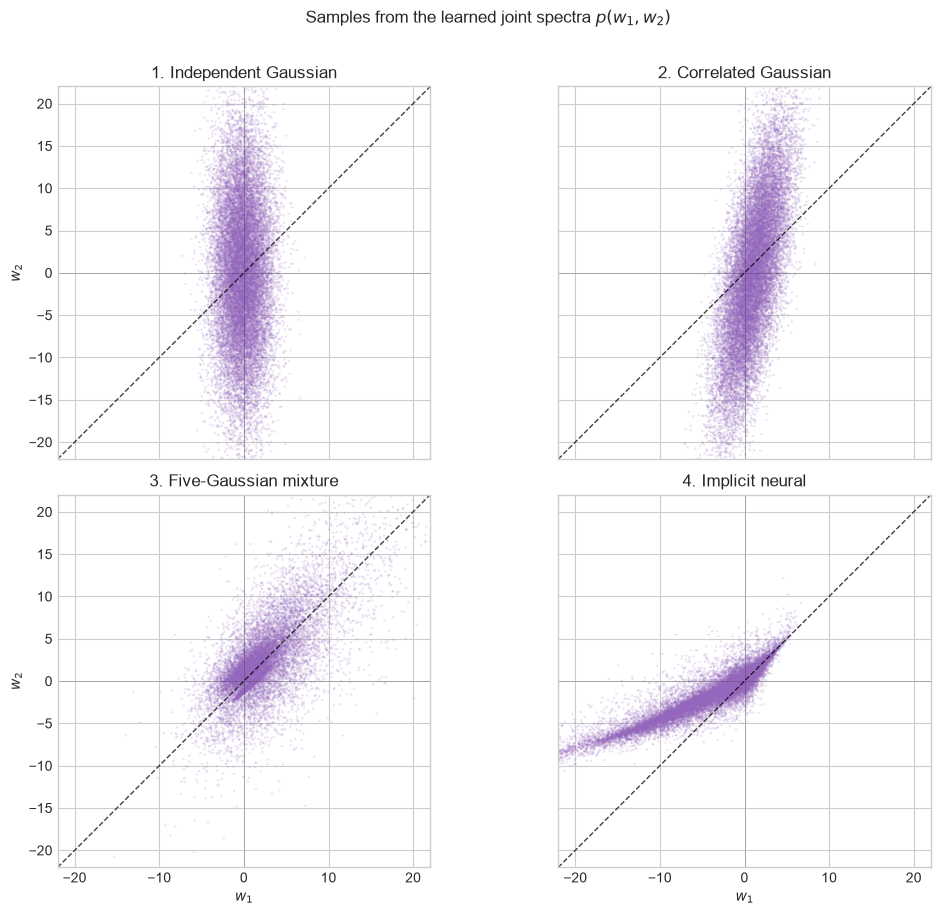

In [538]:
def draw_gaussian_spectral_pairs(kernel, num_samples=20_000, seed=0):
    """Draw from the marginalized Gaussian mixture with deterministic counts."""
    rng = np.random.default_rng(seed)
    means = kernel.means.detach().cpu().numpy()
    stds = kernel.stds.detach().cpu().numpy()
    correlations = kernel.correlations.detach().cpu().numpy()
    mixture_weights = kernel.mixture_weights.detach().cpu().numpy()

    expected_counts = num_samples * mixture_weights
    component_counts = np.floor(expected_counts).astype(int)
    remainder = num_samples - component_counts.sum()
    if remainder:
        fractional_order = np.argsort(-(expected_counts - component_counts))
        component_counts[fractional_order[:remainder]] += 1

    samples = []
    for q in range(kernel.num_components):
        component_count = component_counts[q]
        if component_count == 0:
            continue
        epsilon = rng.standard_normal((component_count, 2))
        rho = correlations[q]
        w1 = means[q, 0] + stds[q, 0] * epsilon[:, 0]
        w2 = means[q, 1] + stds[q, 1] * (
            rho * epsilon[:, 0]
            + np.sqrt(max(1.0 - rho**2, 1e-12)) * epsilon[:, 1]
        )
        samples.append(np.column_stack((w1, w2)))
    return np.vstack(samples)


def draw_implicit_spectral_pairs(kernel, num_samples=20_000, seed=0):
    """Push fresh base noise through the learned neural spectral generator."""
    parameter = next(kernel.generator.parameters())
    noise_dimension = kernel.generator[0].in_features
    cpu_generator = torch.Generator(device="cpu").manual_seed(seed)
    base_noise = torch.randn(
        num_samples, noise_dimension, generator=cpu_generator, dtype=parameter.dtype
    ).to(parameter.device)
    with torch.no_grad():
        pairs = kernel.frequency_scale * kernel.generator(base_noise)
    return pairs.detach().cpu().numpy()


spectral_draws = {
    "1. Independent Gaussian": draw_gaussian_spectral_pairs(
        independent_kernel, seed=seed + 401
    ),
    "2. Correlated Gaussian": draw_gaussian_spectral_pairs(
        correlated_kernel, seed=seed + 402
    ),
    "3. Five-Gaussian mixture": draw_gaussian_spectral_pairs(
        mixture_kernel, seed=seed + 403
    ),
    "4. Implicit neural": draw_implicit_spectral_pairs(
        paired_implicit_kernel, seed=seed + 404
    ),
}

# A robust shared range prevents a few tail samples from compressing every panel.
all_pairs = np.vstack(list(spectral_draws.values()))
frequency_limit = max(1.0, float(np.quantile(np.abs(all_pairs), 0.995)))
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, pairs) in zip(axes.flat, spectral_draws.items()):
    ax.scatter(
        pairs[:, 0], pairs[:, 1], s=3, alpha=0.18, color="tab:purple",
        edgecolors="none", rasterized=True,
    )
    ax.plot(
        [-frequency_limit, frequency_limit], [-frequency_limit, frequency_limit],
        color="black", linestyle="--", linewidth=1.0, alpha=0.75,
    )
    ax.axhline(0.0, color="black", linewidth=0.5, alpha=0.25)
    ax.axvline(0.0, color="black", linewidth=0.5, alpha=0.25)
    ax.set_xlim(-frequency_limit, frequency_limit)
    ax.set_ylim(-frequency_limit, frequency_limit)
    ax.set_title(name)
    ax.set_aspect("equal", adjustable="box")

for ax in axes[-1, :]:
    ax.set_xlabel(r"$w_1$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$w_2$")
fig.suptitle(r"Samples from the learned joint spectra $p(w_1,w_2)$", y=1.01)
fig.tight_layout()
plt.show()

### Gaussian conditioning with a learned kernel

For conditioning indices $o$, learned mean $m$, signal covariance $\widehat K$, and noise variance $\widehat\sigma_n^2$, the latent posterior on the complete grid is

$$
\begin{aligned}
\mathbb E[\mathbf f\mid\mathbf y_o]&=m\mathbf1+\widehat K_{:,o}
(\widehat K_{o,o}+\widehat\sigma_n^2I)^{-1}(\mathbf y_o-m\mathbf1),\\
\operatorname{Cov}(\mathbf f\mid\mathbf y_o)&=\widehat K-\widehat K_{:,o}
(\widehat K_{o,o}+\widehat\sigma_n^2I)^{-1}\widehat K_{o,:}.
\end{aligned}
$$

The following helper uses a Cholesky solve for numerical stability.

In [547]:
def condition_learned_gp(model, likelihood, x_tensor, observation_indices, observed_values):
    signal_covariance = learned_signal_covariance(model, x_tensor)
    signal_covariance = 0.5 * (signal_covariance + signal_covariance.T)
    prior_mean = float(model.mean_module.constant.detach().cpu().squeeze())
    noise_variance = float(likelihood.noise.detach().cpu().squeeze())

    K_oo = signal_covariance[np.ix_(observation_indices, observation_indices)]
    K_all_o = signal_covariance[:, observation_indices]
    conditioning_covariance = K_oo + (noise_variance + 1e-6) * np.eye(len(observation_indices))
    cholesky = np.linalg.cholesky(conditioning_covariance)

    centered_observations = observed_values - prior_mean
    alpha = np.linalg.solve(cholesky.T, np.linalg.solve(cholesky, centered_observations))
    posterior_mean = prior_mean + K_all_o @ alpha

    projected = np.linalg.solve(cholesky, K_all_o.T)
    posterior_variance = np.diag(signal_covariance) - np.sum(projected**2, axis=0)
    posterior_std = np.sqrt(np.maximum(posterior_variance, 0.0))
    return posterior_mean, posterior_std

# One fixed sparse design is reused for every signal and for both models.
prediction_rng = np.random.default_rng(seed + 300)
num_conditioning_points = 10
conditioning_indices = np.sort(
    prediction_rng.choice(n_points, size=num_conditioning_points, replace=False)
)
conditioning_x = x[conditioning_indices]
selected_test_rows = [1,2,3,4,5]  # five test signals to visualize

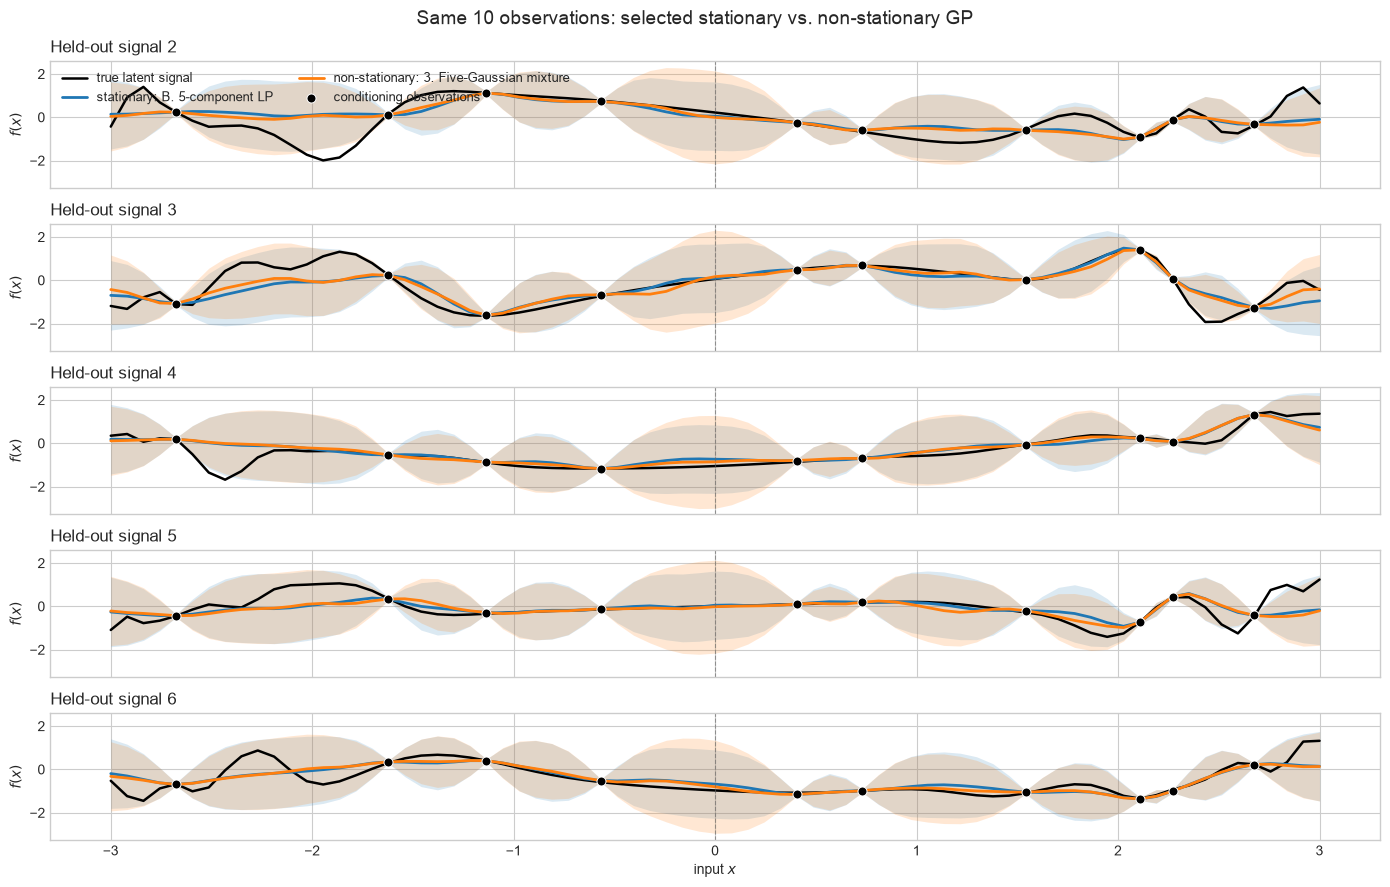

model family,non-stationary,stationary
signal,,
2,0.6462,0.6652
3,0.4493,0.5149
4,0.3652,0.3634
5,0.4812,0.4600
6,0.3752,0.3878


In [548]:
stationary_color = "tab:blue"
nonstationary_color = "tab:orange"
fig, axes = plt.subplots(len(selected_test_rows), 1, figsize=(14, 9), sharex=True, sharey=True)
prediction_rows = []

for panel, test_row in enumerate(selected_test_rows):
    ax = axes[panel]
    population_index = test_indices[test_row]
    latent_test_signal = latent_signals[population_index]
    noisy_test_signal = observed_signals[population_index]
    conditioning_y = noisy_test_signal[conditioning_indices]

    stationary_mean, stationary_std = condition_learned_gp(
        selected_stationary_model, selected_stationary_likelihood, train_x_tensor,
        conditioning_indices, conditioning_y,
    )
    nonstationary_mean, nonstationary_std = condition_learned_gp(
        selected_nonstationary_model, selected_nonstationary_likelihood, train_x_tensor,
        conditioning_indices, conditioning_y,
    )

    ax.plot(x, latent_test_signal, color="black", linewidth=1.8, label="true latent signal")
    ax.plot(x, stationary_mean, color=stationary_color, linewidth=2.0,
            label=f"stationary: {selected_stationary_name}")
    ax.fill_between(
        x, stationary_mean - 1.96 * stationary_std, stationary_mean + 1.96 * stationary_std,
        color=stationary_color, alpha=0.16, linewidth=0,
    )
    ax.plot(x, nonstationary_mean, color=nonstationary_color, linewidth=2.0,
            label=f"non-stationary: {selected_nonstationary_name}")
    ax.fill_between(
        x, nonstationary_mean - 1.96 * nonstationary_std,
        nonstationary_mean + 1.96 * nonstationary_std,
        color=nonstationary_color, alpha=0.18, linewidth=0,
    )
    ax.scatter(conditioning_x, conditioning_y, color="black", edgecolor="white",
               linewidth=0.7, s=42, zorder=5, label="conditioning observations")
    ax.axvline(0.0, color="0.4", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_ylabel(r"$f(x)$")
    ax.set_title(f"Held-out signal {test_row + 1}", loc="left")

    prediction_rows.extend([
        {"signal": test_row + 1, "model family": "stationary",
         "RMSE to latent signal": np.sqrt(np.mean((stationary_mean - latent_test_signal)**2))},
        {"signal": test_row + 1, "model family": "non-stationary",
         "RMSE to latent signal": np.sqrt(np.mean((nonstationary_mean - latent_test_signal)**2))},
    ])

axes[0].legend(ncol=2, fontsize=9, loc="upper left")
axes[-1].set_xlabel(r"input $x$")
fig.suptitle(
    f"Same {num_conditioning_points} observations: selected stationary vs. non-stationary GP",
    fontsize=14,
)
fig.tight_layout()
plt.show()

prediction_table = pd.DataFrame(prediction_rows)
display(prediction_table.pivot(index="signal", columns="model family",
                               values="RMSE to latent signal").style.format(precision=4).set_caption(
    "Posterior-mean RMSE on the displayed held-out signals"
))